In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from load_data_test0 import load_arxiv_data
from preprocessing import clean_dataframe, basic_cleaning, STOPWORDS, nlp

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = load_arxiv_data()
print("raw shape:", df.shape)

df = clean_dataframe(df)
print("cleaned shape:", df.shape)

print(df.columns.tolist())
df.head()

raw shape: (2000, 12)

Cleaning data...
After dropping missing abstracts: 2000 papers. So removed 0
After dropping duplicate IDs: 2000 papers. So removed 0
After dropping duplicate abstracts: 1998 papers. So removed 2
After dropping empty abstracts: 1998 papers. So removed 0
After dropping short abstracts: 1995 papers. So removed 3
After dropping invalid years: 1995 papers. So removed 0

Summary of cleaning:
Total papers removed: 5
Final number of papers: 1995
cleaned shape: (1995, 12)
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions', 'year']


,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year
0,0704.3708,Bernat Corominas-Murtra BCM,Bernat Corominas-Murtra,Network statistics on early English Syntax: St...,"New abstract. Due to a mistake, abstract from ...",None,None,This paper includes a reflection on the role...,None,[cs.CL],"[v1, v2]",2007
1,0705.0693,Tshilidzi Marwala,Evan Hurwitz and Tshilidzi Marwala,Learning to Bluff,6 pages,None,None,The act of bluffing confounds game designers...,None,[cs.AI],[v1],2007
2,0705.0602,Alejandro Chinea Manrique De Lara,Alejandro Chinea Manrique De Lara (INRIA Rocqu...,Risk Assessment Algorithms Based On Recursive ...,None,Dans International Joint Conference On Neural ...,None,The assessment of highly-risky situations at...,None,[cs.NE],[v1],2007
3,0705.1031,Tshilidzi Marwala,F.V. Nelwamondo and T. Marwala,Fuzzy Artmap and Neural Network Approach to On...,7 pages,None,None,An ensemble based approach for dealing with ...,None,[cs.AI],[v1],2007
4,0704.3433,Tshilidzi Marwala,Tshilidzi Marwala and Bodie Crossingham,Bayesian approach to rough set,"20 pages, 3 figures",None,None,This paper proposes an approach to training ...,None,[cs.AI],[v1],2007


In [3]:
def preprocess_abstracts_batch(texts, batch_size=64):
    cleaned = []
    texts_cleaned = [basic_cleaning(text) for text in texts]

    for doc in tqdm(nlp.pipe(texts_cleaned, batch_size=batch_size), total=len(texts_cleaned)):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.text.lower() not in STOPWORDS
            and len(token.text) > 2
            and not token.is_space
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

df["cleaned_abstract"] = preprocess_abstracts_batch(df["abstract"].tolist())

  0%|          | 0/1995 [00:00<?, ?it/s]

In [7]:
import os
import load_data_test0

print("当前 notebook 工作目录：")
print(os.getcwd())

print("\n当前实际导入的 load_data_test0 文件路径：")
print(load_data_test0.__file__)

当前 notebook 工作目录：
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3

当前实际导入的 load_data_test0 文件路径：
F:\Users\lenovo\Desktop\Bristol\AI_and_Text_Analytics_Team33_Task3\load_data_test0.py


In [4]:
df[["abstract", "cleaned_abstract"]].head(5)
#check the result of preprocessing

,abstract,cleaned_abstract
0,This paper includes a reflection on the role...,paper includes reflection role networks study ...
1,The act of bluffing confounds game designers...,act bluffing confounds game designers day natu...
2,The assessment of highly-risky situations at...,assessment highly risky situations road inters...
3,An ensemble based approach for dealing with ...,ensemble based approach dealing missing data w...
4,This paper proposes an approach to training ...,paper proposes approach training rough set mod...


In [5]:
def assign_period(year):
    if year < 2000:
        return "pre-2000"
    elif year < 2005:
        return "2000-2004"
    elif year < 2010:
        return "2005-2009"
    elif year < 2015:
        return "2010-2014"
    elif year < 2020:
        return "2015-2019"
    else:
        return "2020-2025"

df["period"] = df["year"].apply(assign_period)
df["period"].value_counts().sort_index()

period
2005-2009     561
2010-2014    1434
Name: count, dtype: int64

In [6]:
df.to_pickle("person3_preprocessed_sample.pkl")
#保存自己的中间结果—便于不用再重新跑预处理

In [7]:
#建 LDA输入矩阵
texts = df["cleaned_abstract"].fillna("").tolist()

vectorizer = CountVectorizer(
    max_df=0.7,
    min_df=5,
    stop_words="english"
)
##可以调试的更严格如：max_df=0.6,min_df=10

X = vectorizer.fit_transform(texts)

print("X shape:", X.shape)
#把 cleaned_abstract 变成词频矩阵，给 LDA 用（3470是词表大小）

X shape: (1995, 3470)


In [8]:
#训练一个baseline LDA
lda = LatentDirichletAllocation(
    n_components=8,##先尝试8个主题，后续可6
    random_state=42,
    learning_method="batch"
)

doc_topic = lda.fit_transform(X)#每篇摘要属于各个 topic 的概率分布
feature_names = vectorizer.get_feature_names_out()

print("doc_topic shape:", doc_topic.shape)

doc_topic shape: (1995, 8)


In [9]:
#打印每个 topic 的关键词
def print_topics(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_terms = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx}: {', '.join(top_terms)}")

print_topics(lda, feature_names)

Topic 0: learning, data, algorithm, function, algorithms, model, based, problem, models, kernel, linear, methods
Topic 1: variables, inference, problem, algorithm, bayesian, network, networks, model, models, method, graph, structure
Topic 2: data, based, paper, used, using, knowledge, systems, method, information, model, web, human
Topic 3: search, problems, problem, planning, algorithm, constraint, paper, time, algorithms, results, constraints, based
Topic 4: language, logic, based, knowledge, paper, model, information, set, reasoning, semantics, programs, models
Topic 5: fuzzy, learning, data, paper, matrix, using, method, problem, set, present, time, algorithm
Topic 6: algorithm, learning, approach, results, methods, based, number, paper, data, proposed, performance, clustering
Topic 7: algorithm, evolutionary, functions, paper, function, proposed, fitness, information, population, genetic, computational, using


In [10]:
#给每篇文章分配一个主 topic
df["dominant_topic"] = doc_topic.argmax(axis=1)
df[["year", "period", "dominant_topic", "cleaned_abstract"]].head(10)

,year,period,dominant_topic,cleaned_abstract
0,2007,2005-2009,4,paper includes reflection role networks study ...
1,2007,2005-2009,5,act bluffing confounds game designers day natu...
2,2007,2005-2009,7,assessment highly risky situations road inters...
3,2007,2005-2009,2,ensemble based approach dealing missing data w...
4,2007,2005-2009,1,paper proposes approach training rough set mod...
5,2007,2005-2009,3,paper describes system capable semi automatica...
6,2007,2005-2009,2,paper survey large number informal definitions...
7,2007,2005-2009,4,representing reasoning qualitative temporal in...
8,2007,2005-2009,2,noise corruptions variations face images serio...
9,2007,2005-2009,7,paper presents bushing condition monitoring fr...


In [11]:
#看不同时间段的 topic 分布
topic_period = pd.crosstab(
    df["period"],
    df["dominant_topic"],
    normalize="index"
)

topic_period
#值：该时期各topic的占比

dominant_topic,0,1,2,3,4,5,6,7
period,,,,,,,,
2005-2009,0.165775,0.078431,0.222816,0.103387,0.167558,0.076649,0.087344,0.098039
2010-2014,0.209902,0.093445,0.184100,0.150628,0.167364,0.058577,0.080893,0.055091


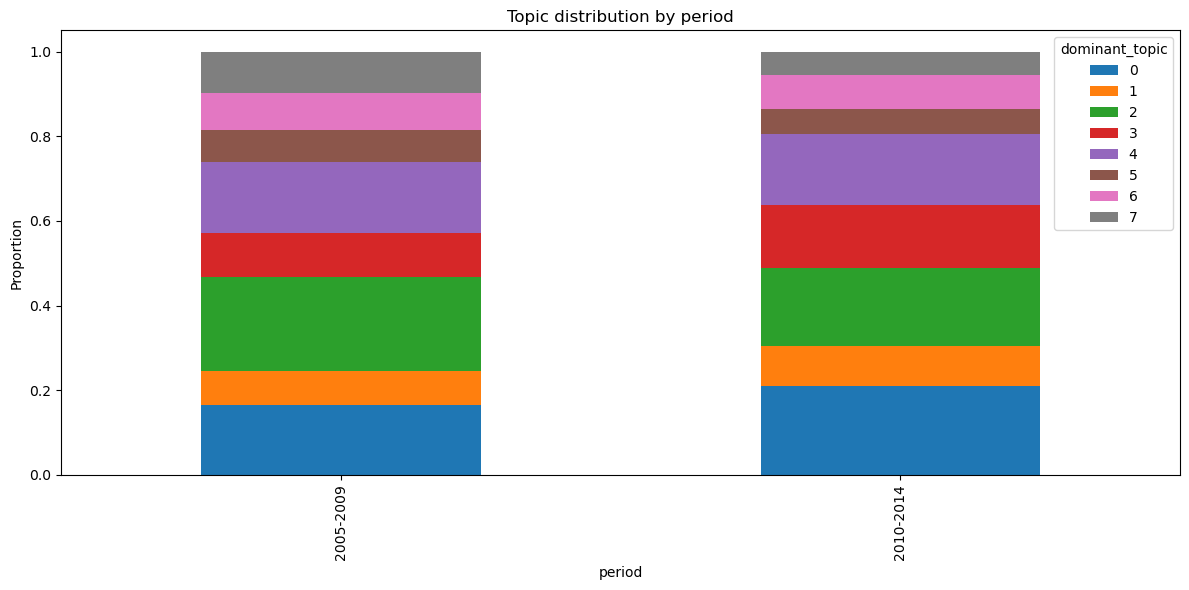

In [12]:
#画 stacked bar 图
topic_period.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [13]:
#topic 0、1、3 在后一个时期更高，而 topic 2、5、7 在前一个时期更高。目前模型具备基本对比能力

In [14]:
#缺陷：topic 可解释性偏弱。在words中存在很多佷泛的学术词（#However, many extracted topics are dominated by generic academic vocabulary, which reduces interpretability）

In [15]:
#改进LDA：提升interpretability

In [17]:
custom_stopwords = {
    "paper", "approach", "method", "methods", "model", "models",
    "problem", "problems", "algorithm", "algorithms",
    "based", "using", "use", "used", "proposed", "propose",
    "result", "results", "data", "set", "information",
    "function", "functions", "study", "present", "work"
}

In [18]:
#baseline2：改 stopwords + 参数 + topic 数
vectorizer2 = CountVectorizer(
    max_df=0.6,
    min_df=10,
    stop_words="english",
    ngram_range=(1, 2)#更容易看见短语，比单个单词更易解释
)

X2 = vectorizer2.fit_transform(df["cleaned_abstract"].fillna(""))
feature_names2 = vectorizer2.get_feature_names_out()

# 手动删一遍自定义停用词对应列
keep_idx = [i for i, term in enumerate(feature_names2) if term not in custom_stopwords]
X2 = X2[:, keep_idx]
feature_names2 = feature_names2[keep_idx]

In [19]:
lda2 = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    learning_method="batch"
)

doc_topic2 = lda2.fit_transform(X2)

In [20]:
print_topics(lda2, feature_names2)

Topic 0: learning, linear, kernel, number, regression, distribution, performance, class, optimization, loss, dimensional, classification
Topic 1: search, language, planning, domain, semantic, text, constraint, new, domains, words, techniques, processing
Topic 2: new, features, different, performance, classification, feature, learning, measure, accuracy, real, analysis, clustering
Topic 3: network, knowledge, neural, time, systems, intelligence, agents, optimization, process, agent, evolutionary, artificial
Topic 4: inference, decision, fuzzy, time, state, value, optimal, new, variables, networks, structure, representation
Topic 5: logic, reasoning, programs, rules, semantics, knowledge, constraints, programming, provide, framework, theory, answer


In [21]:
df["dominant_topic_v2"] = doc_topic2.argmax(axis=1)

topic_period_v2 = pd.crosstab(
    df["period"],
    df["dominant_topic_v2"],
    normalize="index"
)

topic_period_v2

dominant_topic_v2,0,1,2,3,4,5
period,,,,,,
2005-2009,0.212121,0.233512,0.140820,0.213904,0.089127,0.110517
2010-2014,0.228731,0.200139,0.112971,0.181311,0.156206,0.120642


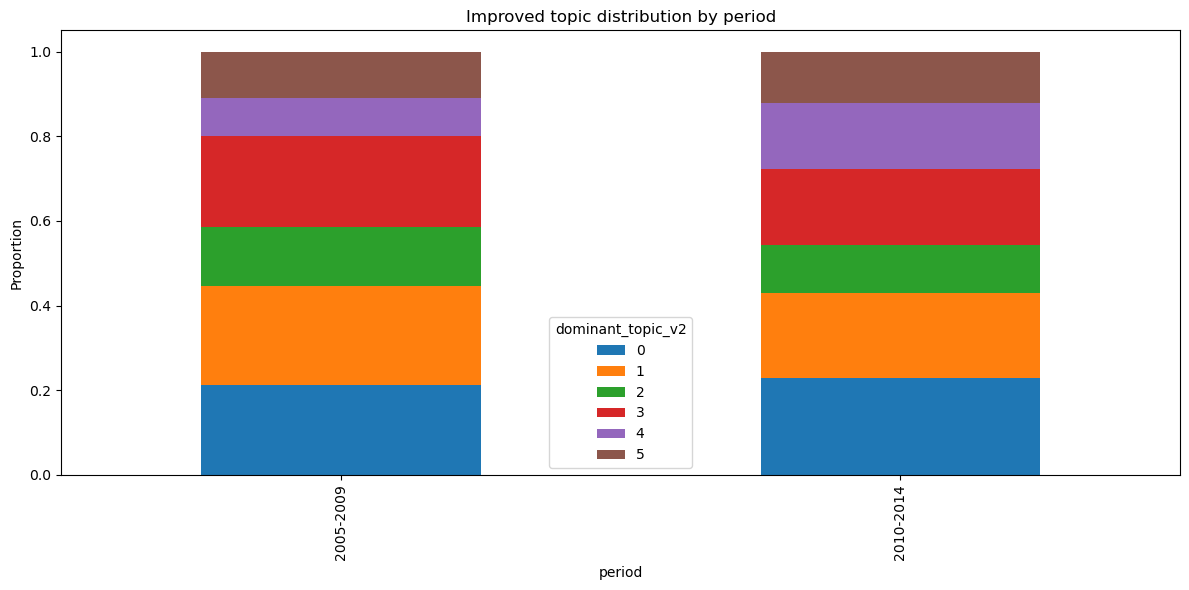

In [22]:
topic_period_v2.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Improved topic distribution by period")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [23]:
#测试2中：明显前一时期topic1（language）,2（cluster&classification）,3（neural network）占比更多。后一时期topic0（regression）,4（fuzzy）占比更多

In [24]:
#缺陷：topic的解释性偏弱

In [ ]:
#改进：提升Topic的质量，之后再将时间覆盖范围扩大。